# Task 2: Exploratory Data Analysis and Storytelling

This section explores the cleaned Milano Cortina 2026 athlete dataset to understand medal patterns, USA vs Canada performance differences, sport portfolio strategy, athlete peak-performance windows, GDP/tradition effects, and the physiological profile of Olympic medalists.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
sns.set_style("whitegrid")

In [3]:
#Loading the cleaned dataset
df = pd.read_csv("milan_cortina_2026_cleaned.csv")
df.head()

,Athlete_ID,Athlete_Name,Country,Gender,Age,Sport,Previous_Olympics,Training_Hours_Per_Week,Altitude_Training_m,Body_Fat_Pct,VO2max,Reaction_Time_ms,Career_Injuries,World_Cup_Points_Preseason,Country_GDP_per_capita,Winter_Sport_Tradition_Index,Medal,Reaction_Time_Missing,WorldCupPoints_Missing,Medal_Won,Experience_Index,VO2_BodyFat_Ratio,GDP_Tradition_Score
0,MC26_1001,Ben Ogden,USA,M,26.0,Cross-Country,1,35.6,1687.0,8.9,91.5,190.0,1,356.0,80000,0.82,Silver,1,0,1,35.6,10.280899,65600.0
1,MC26_1002,Loic Meillard,SUI,M,30.0,Alpine Skiing,3,22.9,2289.0,13.9,71.4,208.0,1,977.0,93000,0.93,Gold,0,0,1,68.7,5.136691,86490.0
2,MC26_1003,Francesca Lollobrigida,ITA,F,35.0,Speed Skating,1,29.0,394.0,10.1,82.6,189.0,3,416.0,38000,0.82,Gold,0,0,1,29.0,8.178218,31160.0
3,MC26_1004,Maria Nilsson,FRA,F,43.0,Ski Jumping,4,26.2,1239.0,9.1,59.3,183.0,2,801.0,48000,0.87,NaN,0,0,0,104.8,6.516484,41760.0
4,MC26_1005,Nils Lewis,GER,M,20.0,Short Track,0,20.2,67.0,12.3,63.1,187.0,2,393.0,52000,0.88,NaN,0,0,0,0.0,5.130081,45760.0


## Q2.1 The Battle of North America: USA vs Canada by the Data

This section compares USA and Canada across medal outcomes, athlete performance indicators, training variables, experience, injuries, and sport portfolio distribution.

In [3]:
#Subsetting USA/Canada

na_df = df[df["Country"].isin(["USA", "CAN"])].copy()
na_df.shape

(94, 23)

In [4]:
na_df["Country"].value_counts()

Country
CAN    48
USA    46
Name: count, dtype: int64

## Q2.1 The Battle of North America; USA vs Canada

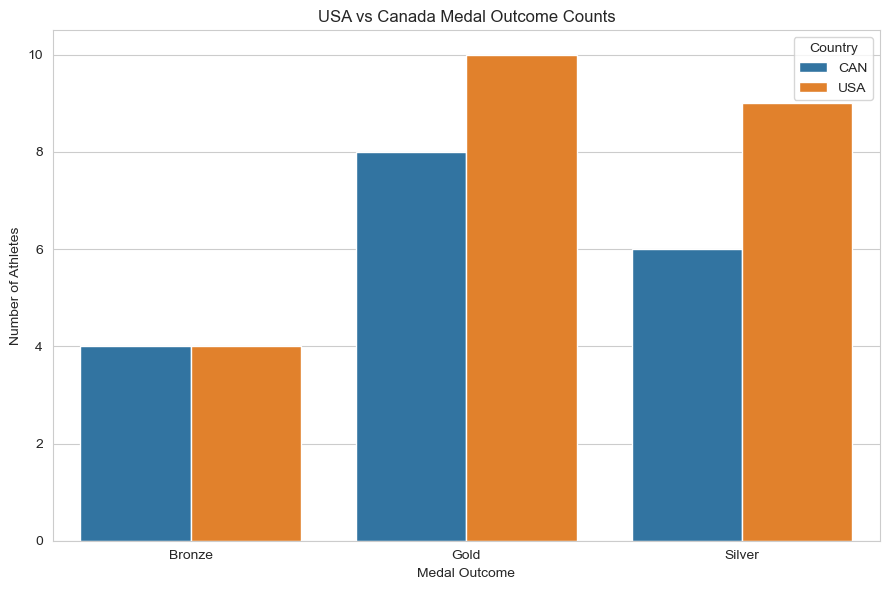

In [6]:
#USA vs Canada Medal Count

medal_counts = (
    na_df.groupby(["Country", "Medal"])
    .size()
    .reset_index(name="Count")
)

plt.figure(figsize=(9, 6))
sns.barplot(data=medal_counts, x="Medal", y="Count", hue="Country")

plt.title("USA vs Canada Medal Outcome Counts")
plt.xlabel("Medal Outcome")
plt.ylabel("Number of Athletes")
plt.legend(title="Country")
plt.tight_layout()

# Save chart
plt.savefig(
    r"C:\Users\User\Desktop\Data Analytics Olympiad\01_usa_canada_medal_counts.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

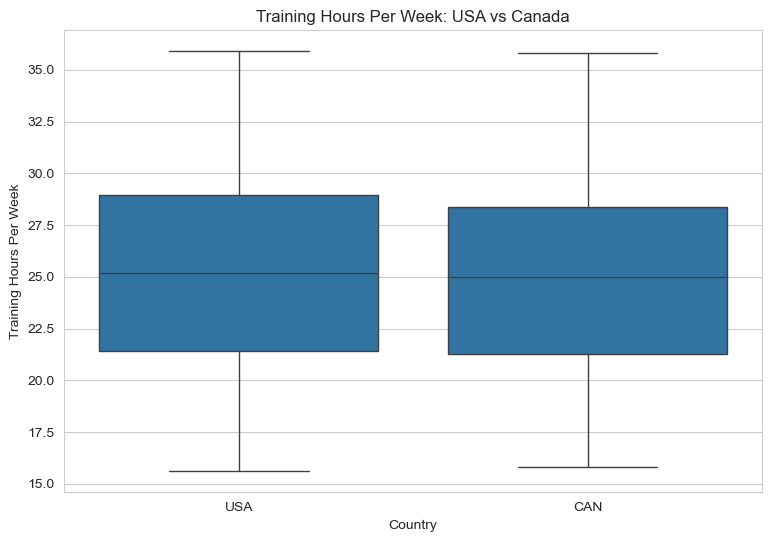

In [7]:
#USA vs Canada Training Hours Comparison

plt.figure(figsize=(9,6))

sns.boxplot(data=na_df, x="Country", y="Training_Hours_Per_Week")

plt.title("Training Hours Per Week: USA vs Canada")
plt.xlabel("Country")
plt.ylabel("Training Hours Per Week")

plt.savefig(
    r"C:\Users\User\Desktop\Data Analytics Olympiad\02_training_hours_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

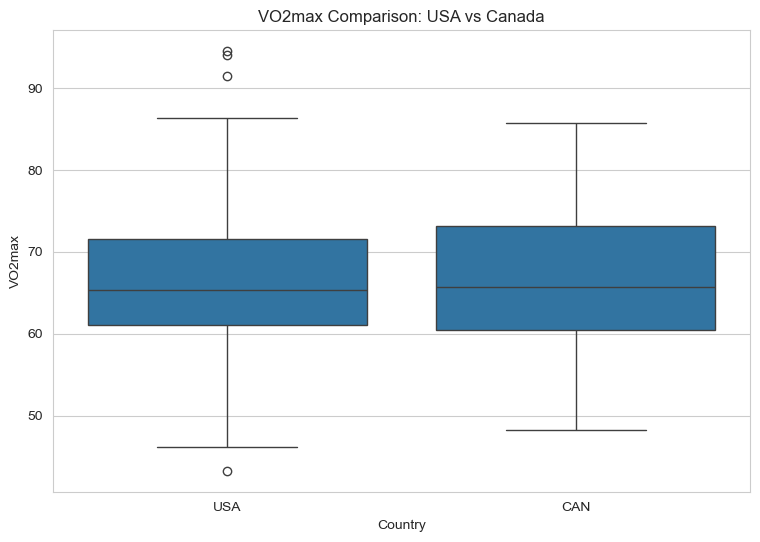

In [8]:
#VO2max Comparison: USA vs Canada

plt.figure(figsize=(9,6))

sns.boxplot(data=na_df, x="Country", y="VO2max")

plt.title("VO2max Comparison: USA vs Canada")
plt.xlabel("Country")
plt.ylabel("VO2max")

plt.savefig(
    r"C:\Users\User\Desktop\Data Analytics Olympiad\03_vo2max_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

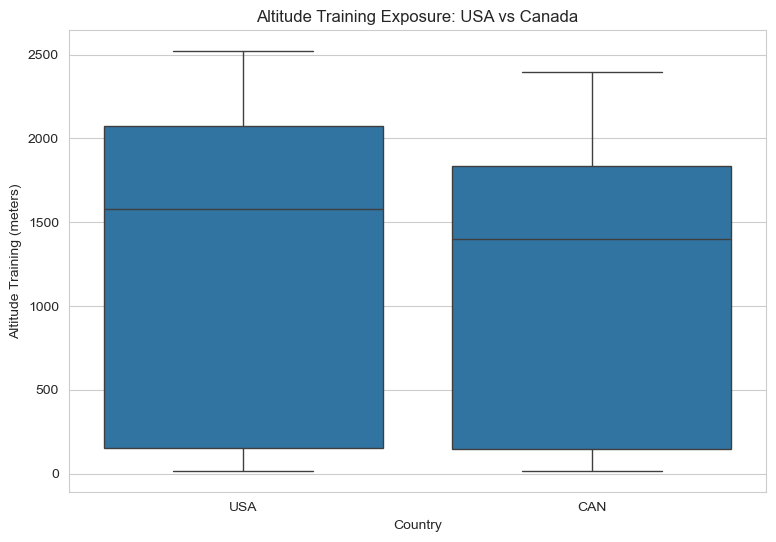

In [9]:
#Altitude Training Comparison
plt.figure(figsize=(9,6))

sns.boxplot(data=na_df, x="Country", y="Altitude_Training_m")

plt.title("Altitude Training Exposure: USA vs Canada")
plt.xlabel("Country")
plt.ylabel("Altitude Training (meters)")

plt.savefig(
    r"C:\Users\User\Desktop\Data Analytics Olympiad\04_altitude_training_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

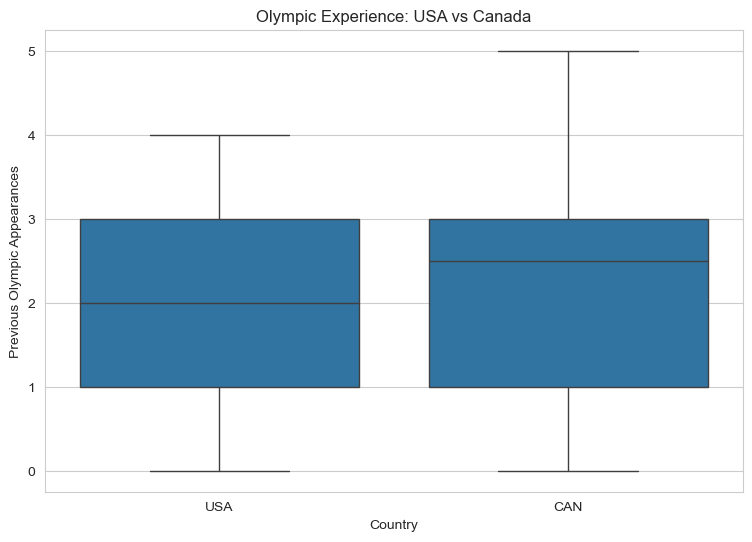

In [10]:
#Previous Olympic Experience
plt.figure(figsize=(9,6))

sns.boxplot(data=na_df, x="Country", y="Previous_Olympics")

plt.title("Olympic Experience: USA vs Canada")
plt.xlabel("Country")
plt.ylabel("Previous Olympic Appearances")

plt.savefig(
    r"C:\Users\User\Desktop\Data Analytics Olympiad\05_olympic_experience_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

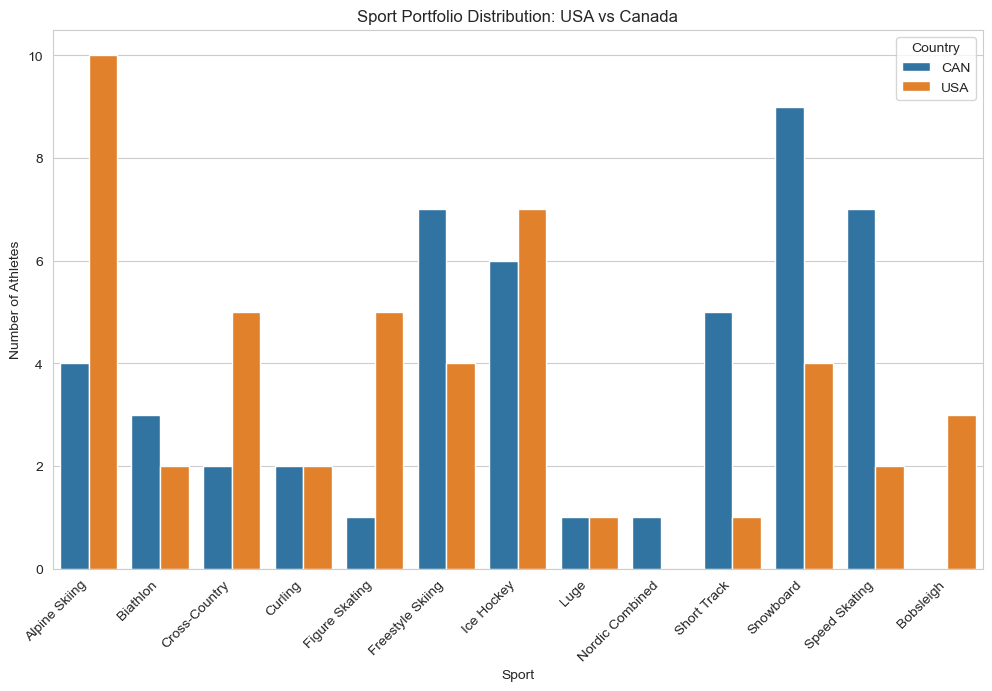

In [11]:
#Sport Portfolio Distribution
sport_counts = (
    na_df.groupby(["Country", "Sport"])
    .size()
    .reset_index(name="Count")
)

plt.figure(figsize=(12,7))

sns.barplot(data=sport_counts, x="Sport", y="Count", hue="Country")

plt.title("Sport Portfolio Distribution: USA vs Canada")
plt.xlabel("Sport")
plt.ylabel("Number of Athletes")
plt.xticks(rotation=45, ha="right")

plt.savefig(
    r"C:\Users\User\Desktop\Data Analytics Olympiad\06_sport_portfolio_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# Q2.2 Anatomy of a Gold Medal  — USA & CANADA ONLY
# Medal Outcome Analysis for North American Athletes

In [25]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Filter dataset to USA and Canada only
na_df = df[df["Country"].isin(["USA", "CAN"])].copy()

# Create medal grouping
na_df["Medal_Group"] = na_df["Medal"].fillna("None")

# Set style
sns.set(style="whitegrid")

In [12]:
# Anatomy of a Gold Medal Winner

medal_order = ["Gold", "Silver", "Bronze", "None"]

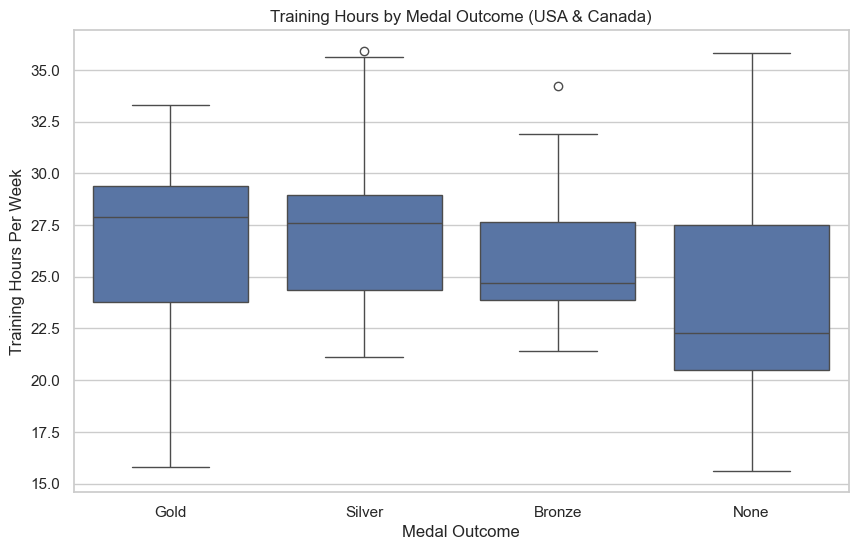

In [26]:
#Training Hours by Medal Group
plt.figure(figsize=(10,6))

sns.boxplot(
    data=na_df,
    x="Medal_Group",
    y="Training_Hours_Per_Week",
    order=["Gold","Silver","Bronze","None"]
)

plt.title("Training Hours by Medal Outcome (USA & Canada)")
plt.xlabel("Medal Outcome")
plt.ylabel("Training Hours Per Week")

plt.savefig(
    r"C:\Users\User\Desktop\Data Analytics Olympiad\07_training_by_medal_group_fixed.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

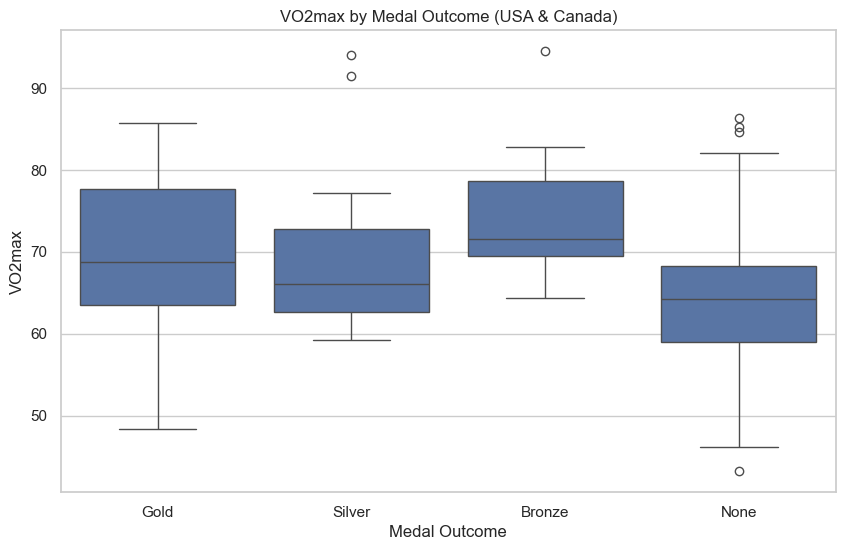

In [28]:
#VO2max by Medal Outcome
plt.figure(figsize=(10,6))

sns.boxplot(
    data=na_df,
    x="Medal_Group",
    y="VO2max",
    order=["Gold","Silver","Bronze","None"]
)

plt.title("VO2max by Medal Outcome (USA & Canada)")
plt.xlabel("Medal Outcome")
plt.ylabel("VO2max")

plt.savefig(
    r"C:\Users\User\Desktop\Data Analytics Olympiad\08_vo2max_by_medal_group_fixed.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

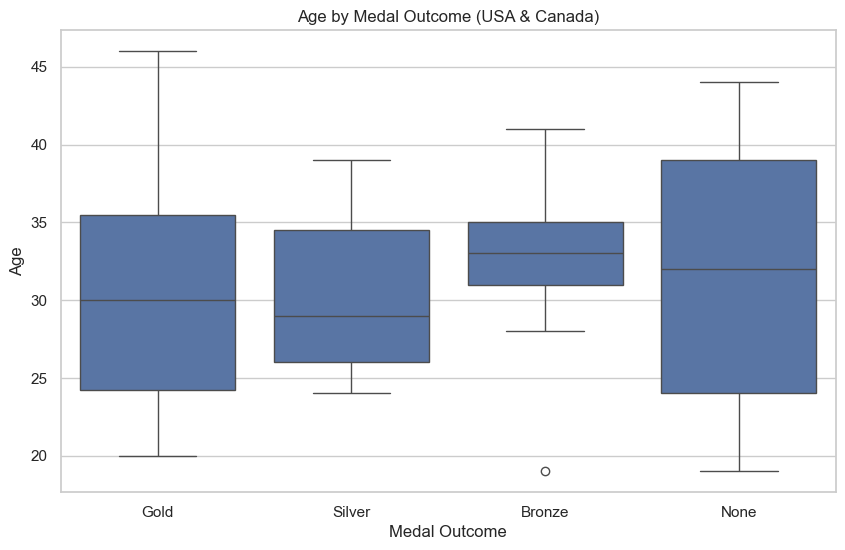

In [29]:
#Age by Medal Outcome
plt.figure(figsize=(10,6))

sns.boxplot(
    data=na_df,
    x="Medal_Group",
    y="Age",
    order=["Gold","Silver","Bronze","None"]
)

plt.title("Age by Medal Outcome (USA & Canada)")
plt.xlabel("Medal Outcome")
plt.ylabel("Age")

plt.savefig(
    r"C:\Users\User\Desktop\Data Analytics Olympiad\09_age_by_medal_group_fixed.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

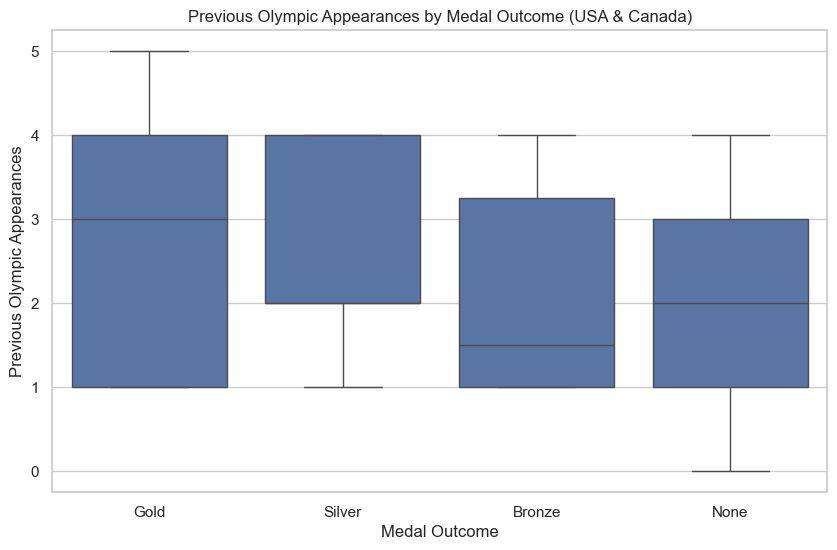

In [31]:
#Previous Olympic Experience by Medal Outcome
plt.figure(figsize=(10,6))

sns.boxplot(
    data=na_df,
    x="Medal_Group",
    y="Previous_Olympics",
    order=["Gold","Silver","Bronze","None"]
)

plt.title("Previous Olympic Appearances by Medal Outcome (USA & Canada)")
plt.xlabel("Medal Outcome")
plt.ylabel("Previous Olympic Appearances")

plt.savefig(
    r"C:\Users\User\Desktop\Data Analytics Olympiad\10_experience_by_medal_group_fixed.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# Q2.3 — Which Sports Produce the Most Medals

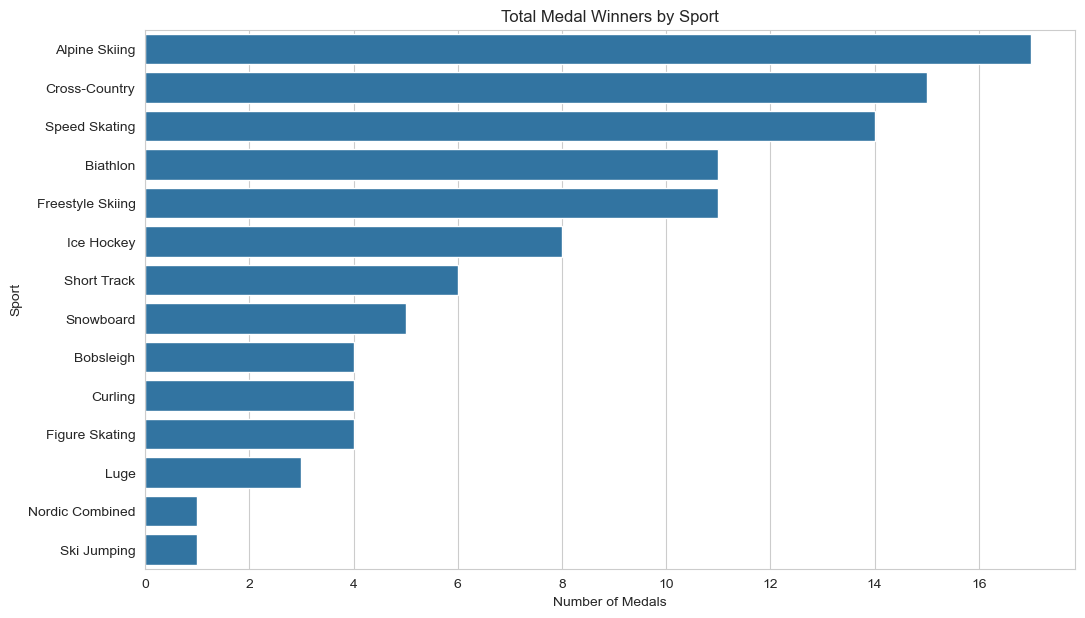

In [21]:
#Medal Counts by Sport

medal_df = df[df["Medal_Group"] != "None"]

sport_medals = (
    medal_df.groupby("Sport")
    .size()
    .reset_index(name="Medal_Count")
    .sort_values("Medal_Count", ascending=False)
)

plt.figure(figsize=(12,7))

sns.barplot(
    data=sport_medals,
    x="Medal_Count",
    y="Sport"
)

plt.title("Total Medal Winners by Sport")
plt.xlabel("Number of Medals")
plt.ylabel("Sport")

plt.savefig(
    r"C:\Users\User\Desktop\Data Analytics Olympiad\12_total_medals_by_sport.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

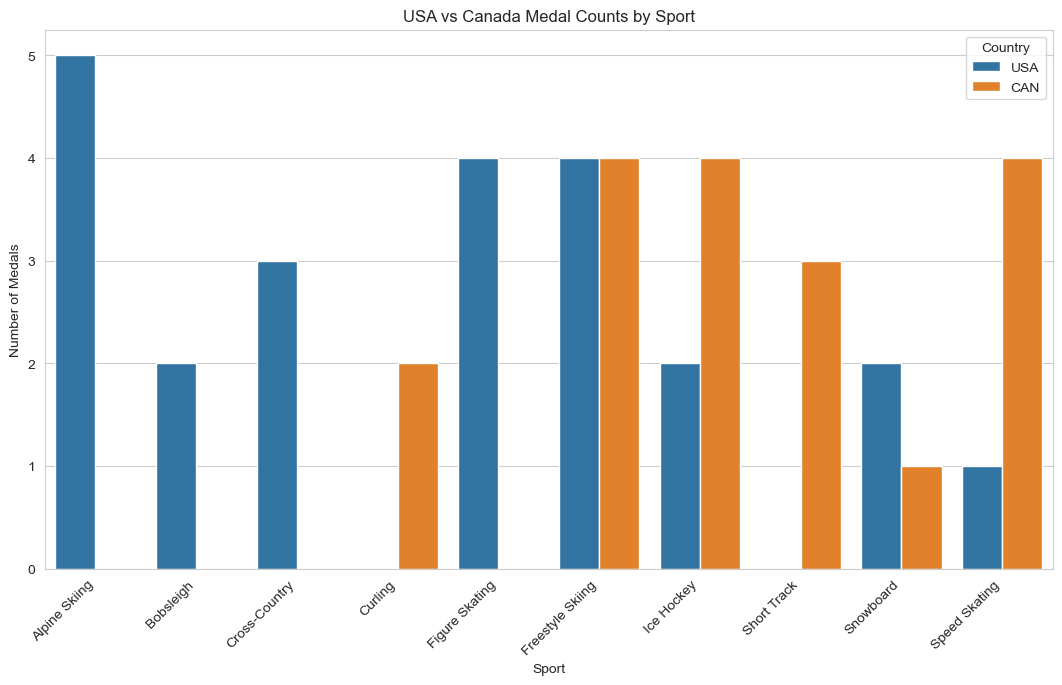

In [23]:
# Keep only USA and Canada
na_df = df[df["Country"].isin(["USA", "CAN"])]

# Medal winners only
na_medals = na_df[na_df["Medal_Group"] != "None"]

# Count medals by sport + country
sport_country = (
    na_medals.groupby(["Sport", "Country"])
    .size()
    .reset_index(name="Medal_Count")
)

plt.figure(figsize=(13,7))

sns.barplot(
    data=sport_country,
    x="Sport",
    y="Medal_Count",
    hue="Country"
)

plt.title("USA vs Canada Medal Counts by Sport")
plt.xlabel("Sport")
plt.ylabel("Number of Medals")
plt.xticks(rotation=45, ha="right")

plt.savefig(
    r"C:\Users\User\Desktop\Data Analytics Olympiad\13_usa_canada_medals_by_sport_FIXED.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

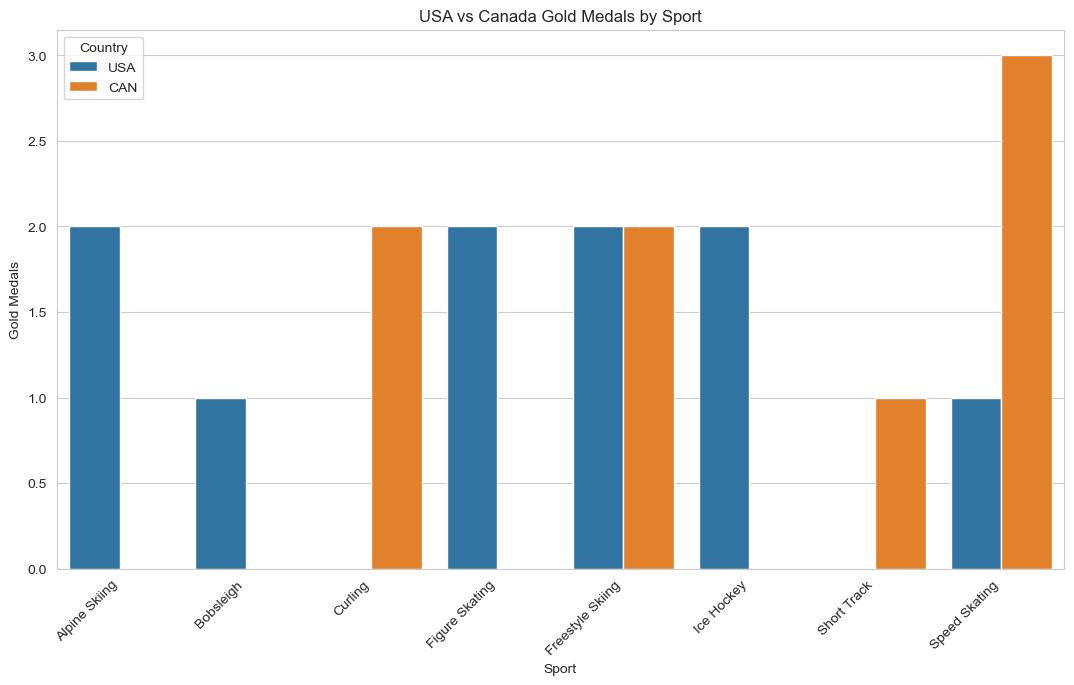

In [24]:
#Gold Medals by Sport — USA vs Canada
gold_df = na_df[na_df["Medal_Group"] == "Gold"]

gold_sport = (
    gold_df.groupby(["Sport", "Country"])
    .size()
    .reset_index(name="Gold_Count")
)

plt.figure(figsize=(13,7))

sns.barplot(
    data=gold_sport,
    x="Sport",
    y="Gold_Count",
    hue="Country"
)

plt.title("USA vs Canada Gold Medals by Sport")
plt.xlabel("Sport")
plt.ylabel("Gold Medals")
plt.xticks(rotation=45, ha="right")

plt.savefig(
    r"C:\Users\User\Desktop\Data Analytics Olympiad\14_gold_medals_by_sport.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# Q2.4 — Age & Peak Performance Window

C:\Users\User\AppData\Local\Temp\ipykernel_24276\3852067244.py:21: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  na_df.groupby(["Age_Group", "Country"])["Won_Medal"]


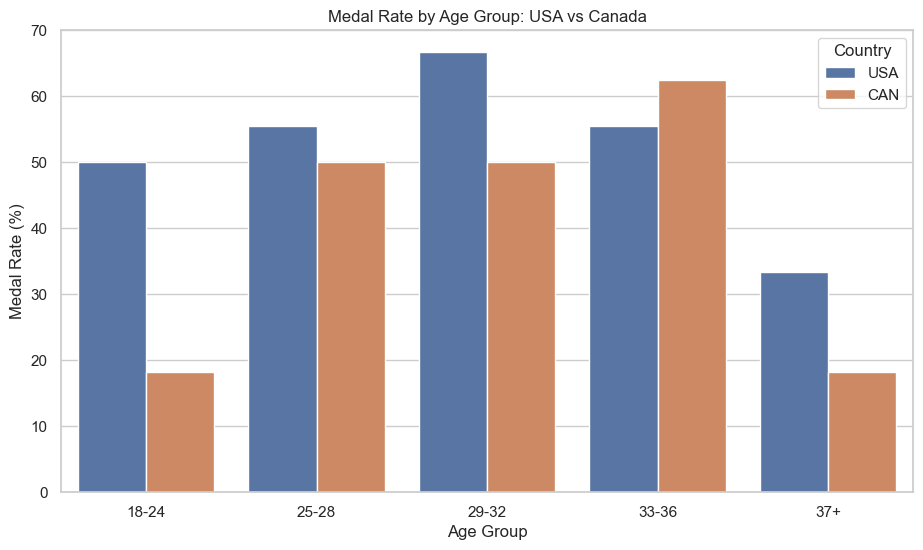

In [36]:
#Medal Rate by Age Group
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# USA + Canada only
na_df = df[df["Country"].isin(["USA", "CAN"])].copy()

# Medal flag
na_df["Won_Medal"] = (na_df["Medal_Group"] != "None").astype(int)

# Age groups
na_df["Age_Group"] = pd.cut(
    na_df["Age"],
    bins=[18,24,28,32,36,50],
    labels=["18-24","25-28","29-32","33-36","37+"]
)

# Medal rate by country + age group
age_country = (
    na_df.groupby(["Age_Group", "Country"])["Won_Medal"]
    .mean()
    .reset_index()
)

age_country["Won_Medal"] *= 100

plt.figure(figsize=(11,6))

sns.barplot(
    data=age_country,
    x="Age_Group",
    y="Won_Medal",
    hue="Country",
    hue_order=["USA", "CAN"]
)

plt.title("Medal Rate by Age Group: USA vs Canada")
plt.xlabel("Age Group")
plt.ylabel("Medal Rate (%)")
plt.legend(title="Country")

plt.savefig(
    r"C:\Users\User\Desktop\Data Analytics Olympiad\15_medal_rate_agegroup_USA_CAN.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

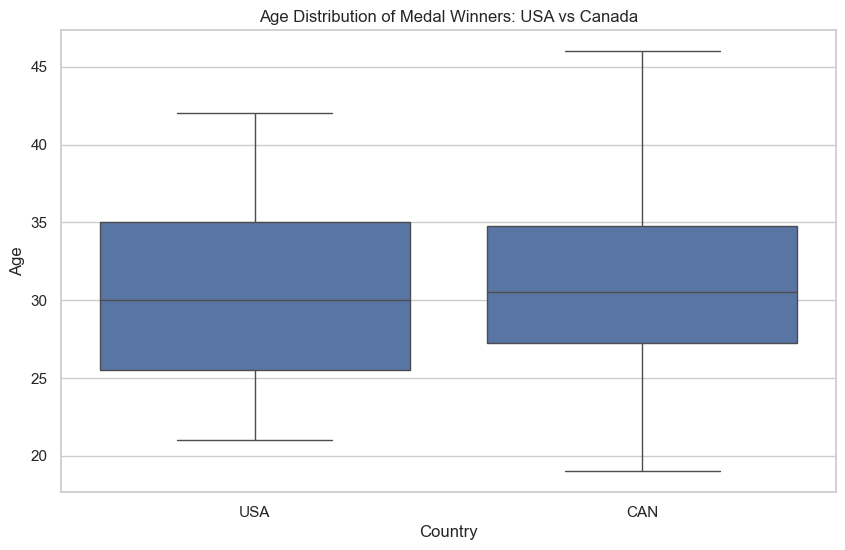

In [37]:
#Average Medal Winner Age: USA vs Canada

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# USA + Canada only
na_df = df[df["Country"].isin(["USA", "CAN"])].copy()

# Medal winners only
medal_df = na_df[na_df["Medal_Group"] != "None"].copy()

# Plot
plt.figure(figsize=(10,6))

sns.boxplot(
    data=medal_df,
    x="Country",
    y="Age",
    order=["USA", "CAN"]
)

plt.title("Age Distribution of Medal Winners: USA vs Canada")
plt.xlabel("Country")
plt.ylabel("Age")

plt.savefig(
    r"C:\Users\User\Desktop\Data Analytics Olympiad\16_age_medalists_USA_CAN.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

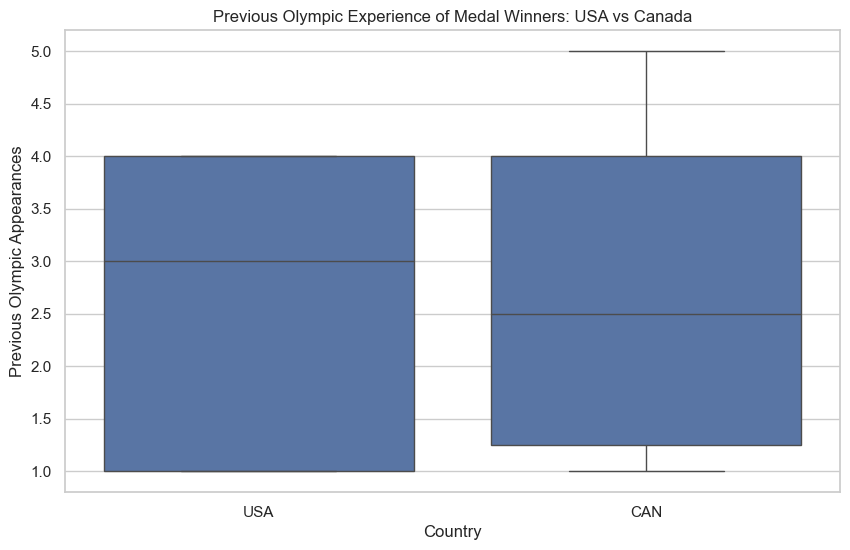

In [39]:
# Previous Olympic Experience: USA vs Canada

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# USA + Canada only
na_df = df[df["Country"].isin(["USA", "CAN"])].copy()

# Medal winners only
medal_df = na_df[na_df["Medal_Group"] != "None"].copy()

plt.figure(figsize=(10,6))

sns.boxplot(
    data=medal_df,
    x="Country",
    y="Previous_Olympics",
    order=["USA", "CAN"]
)

plt.title("Previous Olympic Experience of Medal Winners: USA vs Canada")
plt.xlabel("Country")
plt.ylabel("Previous Olympic Appearances")

plt.savefig(
    r"C:\Users\User\Desktop\Data Analytics Olympiad\17_experience_medalists_USA_CAN.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

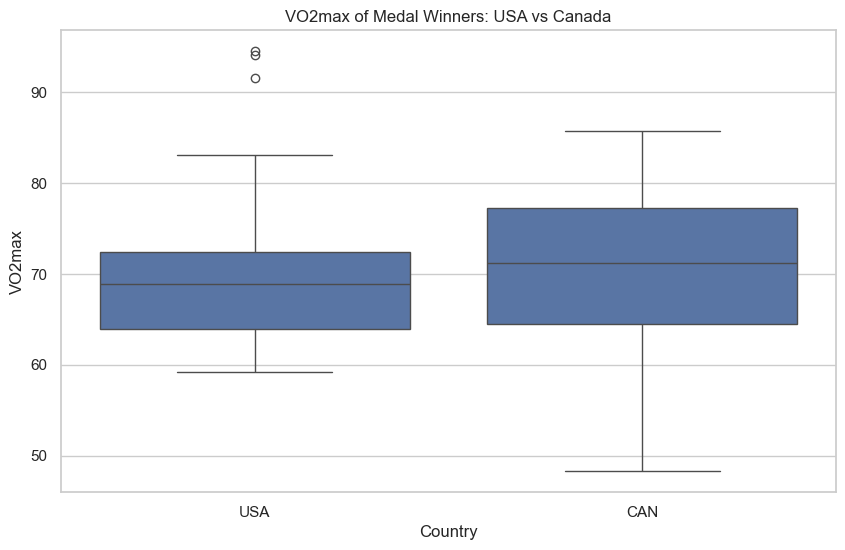

In [40]:
# VO2max of Medal Winners: USA vs Canada

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# USA + Canada only
na_df = df[df["Country"].isin(["USA", "CAN"])].copy()

# Medal winners only
medal_df = na_df[na_df["Medal_Group"] != "None"].copy()

plt.figure(figsize=(10,6))

sns.boxplot(
    data=medal_df,
    x="Country",
    y="VO2max",
    order=["USA", "CAN"]
)

plt.title("VO2max of Medal Winners: USA vs Canada")
plt.xlabel("Country")
plt.ylabel("VO2max")

plt.savefig(
    r"C:\Users\User\Desktop\Data Analytics Olympiad\18_vo2_medalists_USA_CAN.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# Q2.5 — SThe GDP and Tradition Effect

C:\Users\User\AppData\Local\Temp\ipykernel_19400\2089171974.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


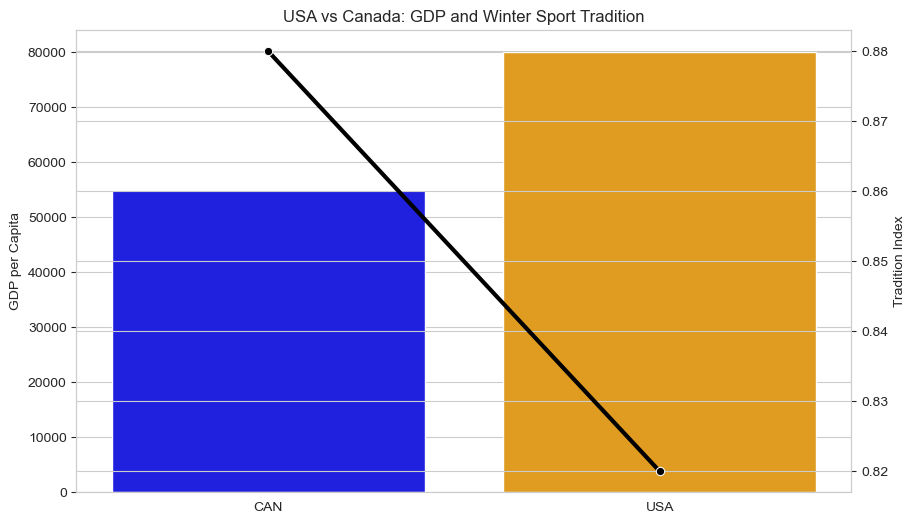

In [6]:
# GDP vs Medal Outcome by Country

# =====================================================
# Q2.5 Better Plot — USA vs Canada GDP + Tradition
# =====================================================

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

compare = df[df["Country"].isin(["USA","CAN"])]

summary = (
    compare.groupby("Country")
    .agg({
        "Country_GDP_per_capita":"mean",
        "Winter_Sport_Tradition_Index":"mean"
    })
    .reset_index()
)

fig, ax1 = plt.subplots(figsize=(10,6))

# GDP bars
sns.barplot(
    data=summary,
    x="Country",
    y="Country_GDP_per_capita",
    palette=["blue","orange"],
    ax=ax1
)

ax1.set_ylabel("GDP per Capita")
ax1.set_xlabel("")
ax1.set_title("USA vs Canada: GDP and Winter Sport Tradition")

# Second axis for tradition
ax2 = ax1.twinx()

sns.lineplot(
    data=summary,
    x="Country",
    y="Winter_Sport_Tradition_Index",
    marker="o",
    linewidth=3,
    color="black",
    ax=ax2
)

ax2.set_ylabel("Tradition Index")

plt.savefig(
r"C:\Users\User\Desktop\Data Analytics Olympiad\26_better_gdp_tradition.png",
dpi=300,
bbox_inches="tight"
)

plt.show()

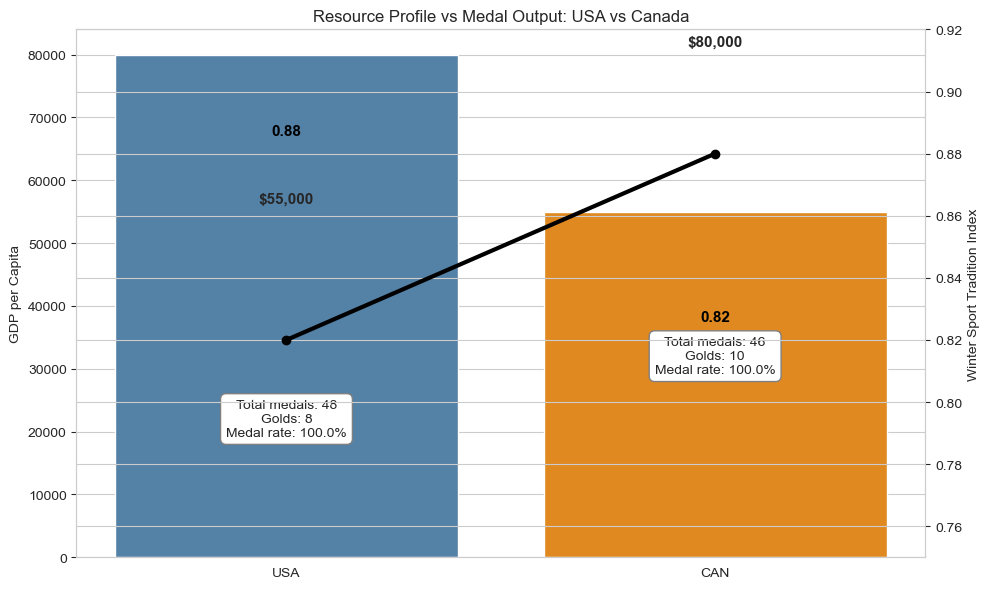

,Country,GDP_per_Capita,Tradition_Index,Medal_Rate,Gold_Count,Total_Medals
1,USA,80000.0,0.82,100.0,10,46
0,CAN,55000.0,0.88,100.0,8,48


In [7]:
# Resource Advantage vs Medal Output

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# USA + Canada only
na_df = df[df["Country"].isin(["USA", "CAN"])].copy()

# Medal flags
na_df["Won_Medal"] = np.where(na_df["Medal"] == "None", 0, 1)
na_df["Gold_Won"] = np.where(na_df["Medal"] == "Gold", 1, 0)

# Summary table
resource_summary = (
    na_df.groupby("Country")
    .agg(
        GDP_per_Capita=("Country_GDP_per_capita", "mean"),
        Tradition_Index=("Winter_Sport_Tradition_Index", "mean"),
        Medal_Rate=("Won_Medal", "mean"),
        Gold_Count=("Gold_Won", "sum"),
        Total_Medals=("Won_Medal", "sum")
    )
    .reset_index()
)

resource_summary["Medal_Rate"] = resource_summary["Medal_Rate"] * 100

# Force USA first
resource_summary["Country"] = pd.Categorical(
    resource_summary["Country"],
    categories=["USA", "CAN"],
    ordered=True
)
resource_summary = resource_summary.sort_values("Country")

# Plot
fig, ax1 = plt.subplots(figsize=(10,6))

sns.barplot(
    data=resource_summary,
    x="Country",
    y="GDP_per_Capita",
    hue="Country",
    palette={"USA":"steelblue", "CAN":"darkorange"},
    legend=False,
    ax=ax1
)

ax1.set_ylabel("GDP per Capita")
ax1.set_xlabel("")
ax1.set_title("Resource Profile vs Medal Output: USA vs Canada")

# Add GDP labels
for i, row in resource_summary.iterrows():
    ax1.text(
        i,
        row["GDP_per_Capita"] + 1500,
        f"${row['GDP_per_Capita']:,.0f}",
        ha="center",
        fontsize=11,
        fontweight="bold"
    )

# Secondary axis for tradition index
ax2 = ax1.twinx()
ax2.plot(
    resource_summary["Country"].astype(str),
    resource_summary["Tradition_Index"],
    color="black",
    marker="o",
    linewidth=3,
    label="Tradition Index"
)

ax2.set_ylabel("Winter Sport Tradition Index")
ax2.set_ylim(0.75, 0.92)

# Add tradition labels
for i, row in resource_summary.iterrows():
    ax2.text(
        i,
        row["Tradition_Index"] + 0.006,
        f"{row['Tradition_Index']:.2f}",
        ha="center",
        fontsize=11,
        fontweight="bold",
        color="black"
    )

# Add medal summary boxes
for i, row in resource_summary.iterrows():
    ax1.text(
        i,
        row["GDP_per_Capita"] * 0.40,
        f"Total medals: {int(row['Total_Medals'])}\nGolds: {int(row['Gold_Count'])}\nMedal rate: {row['Medal_Rate']:.1f}%",
        ha="center",
        va="center",
        fontsize=10,
        bbox=dict(boxstyle="round,pad=0.4", facecolor="white", edgecolor="gray")
    )

fig.tight_layout()

plt.savefig(
    r"C:\Users\User\Desktop\Data Analytics Olympiad\26_resource_profile_medal_output_USA_CAN.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

resource_summary

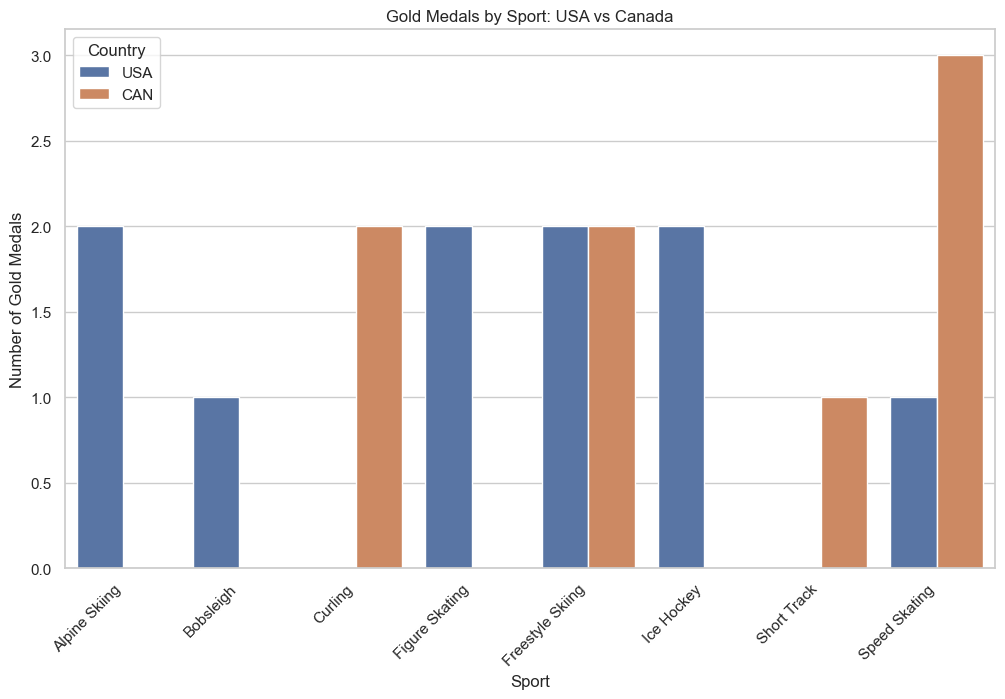

In [42]:
# Gold Medals by Sport: USA vs Canada

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# USA + Canada only
na_df = df[df["Country"].isin(["USA", "CAN"])].copy()

# Gold medal winners only
gold_df = na_df[na_df["Medal_Group"] == "Gold"].copy()

# Count gold medals by sport and country
gold_counts = (
    gold_df.groupby(["Sport", "Country"])
    .size()
    .reset_index(name="Gold_Medals")
)

plt.figure(figsize=(12,7))

sns.barplot(
    data=gold_counts,
    x="Sport",
    y="Gold_Medals",
    hue="Country",
    hue_order=["USA", "CAN"]
)

plt.title("Gold Medals by Sport: USA vs Canada")
plt.xlabel("Sport")
plt.ylabel("Number of Gold Medals")
plt.xticks(rotation=45, ha="right")

plt.savefig(
    r"C:\Users\User\Desktop\Data Analytics Olympiad\20_gold_medals_by_sport_strategy.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# The Physiological Signature of Champions

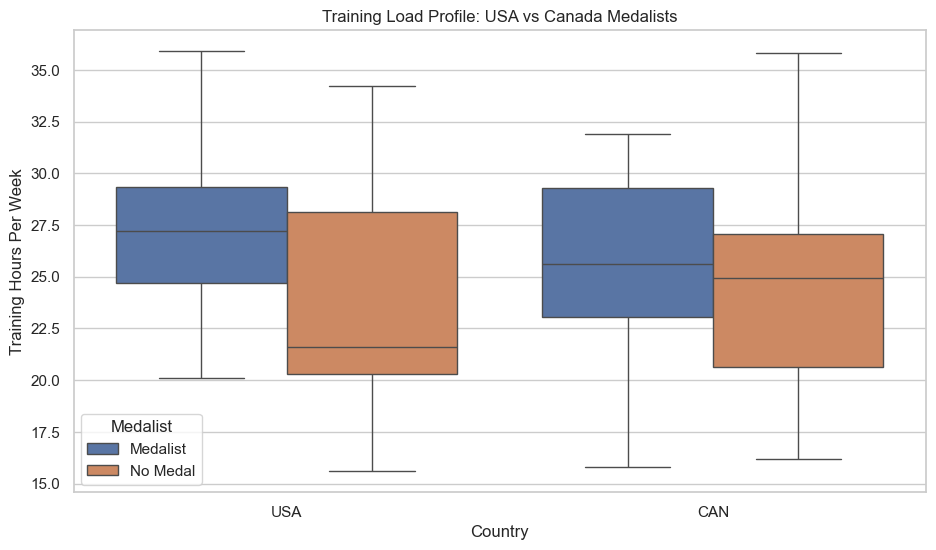

In [43]:
# Training Load of Medalists: USA vs Canada

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# USA + Canada only
na_df = df[df["Country"].isin(["USA", "CAN"])].copy()

# Medalist flag
na_df["Medalist"] = np.where(na_df["Medal_Group"] == "None", "No Medal", "Medalist")

plt.figure(figsize=(11,6))

sns.boxplot(
    data=na_df,
    x="Country",
    y="Training_Hours_Per_Week",
    hue="Medalist",
    order=["USA", "CAN"],
    hue_order=["Medalist", "No Medal"]
)

plt.title("Training Load Profile: USA vs Canada Medalists")
plt.xlabel("Country")
plt.ylabel("Training Hours Per Week")

plt.savefig(
    r"C:\Users\User\Desktop\Data Analytics Olympiad\21_training_load_USA_CAN_medalist.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

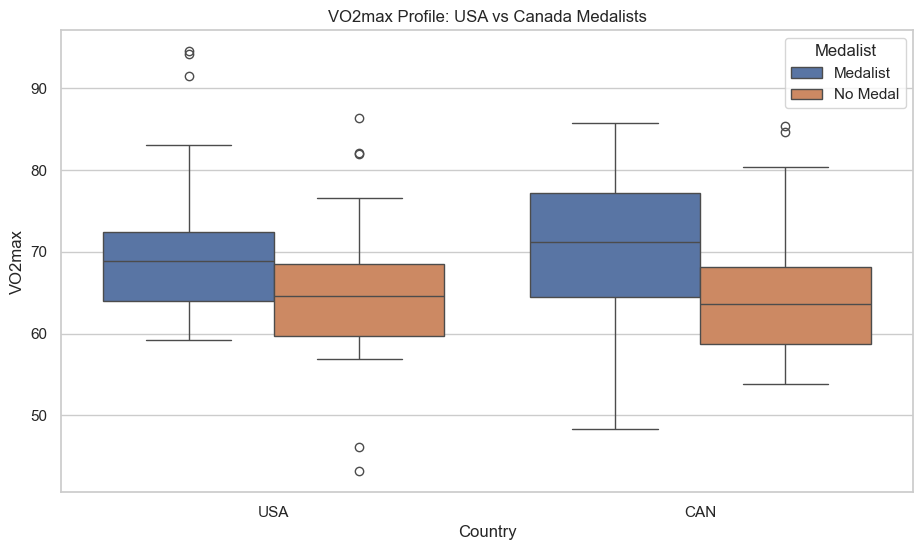

In [44]:
# VO2max Profile: USA vs Canada Medalists

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# USA + Canada only
na_df = df[df["Country"].isin(["USA", "CAN"])].copy()

# Medalist flag
na_df["Medalist"] = np.where(na_df["Medal_Group"] == "None", "No Medal", "Medalist")

plt.figure(figsize=(11,6))

sns.boxplot(
    data=na_df,
    x="Country",
    y="VO2max",
    hue="Medalist",
    order=["USA", "CAN"],
    hue_order=["Medalist", "No Medal"]
)

plt.title("VO2max Profile: USA vs Canada Medalists")
plt.xlabel("Country")
plt.ylabel("VO2max")

plt.savefig(
    r"C:\Users\User\Desktop\Data Analytics Olympiad\22_vo2max_USA_CAN_medalist.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

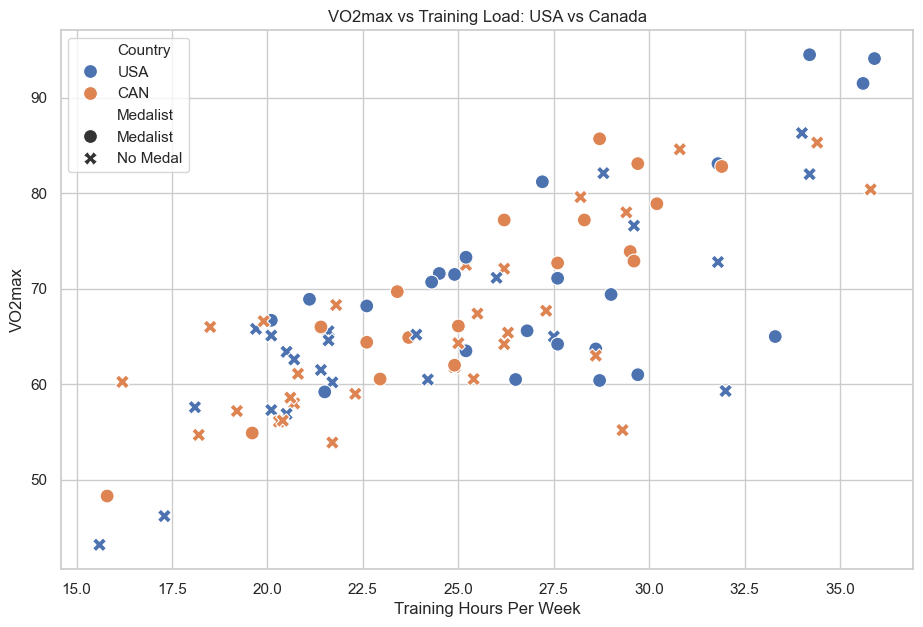

In [45]:
# VO2max vs Training Load (USA vs Canada)

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# USA + Canada only
na_df = df[df["Country"].isin(["USA", "CAN"])].copy()

# Medalist flag
na_df["Medalist"] = np.where(na_df["Medal_Group"] == "None", "No Medal", "Medalist")

plt.figure(figsize=(11,7))

sns.scatterplot(
    data=na_df,
    x="Training_Hours_Per_Week",
    y="VO2max",
    hue="Country",
    style="Medalist",
    s=100
)

plt.title("VO2max vs Training Load: USA vs Canada")
plt.xlabel("Training Hours Per Week")
plt.ylabel("VO2max")

plt.savefig(
    r"C:\Users\User\Desktop\Data Analytics Olympiad\23_vo2_training_overtraining_USA_CAN.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

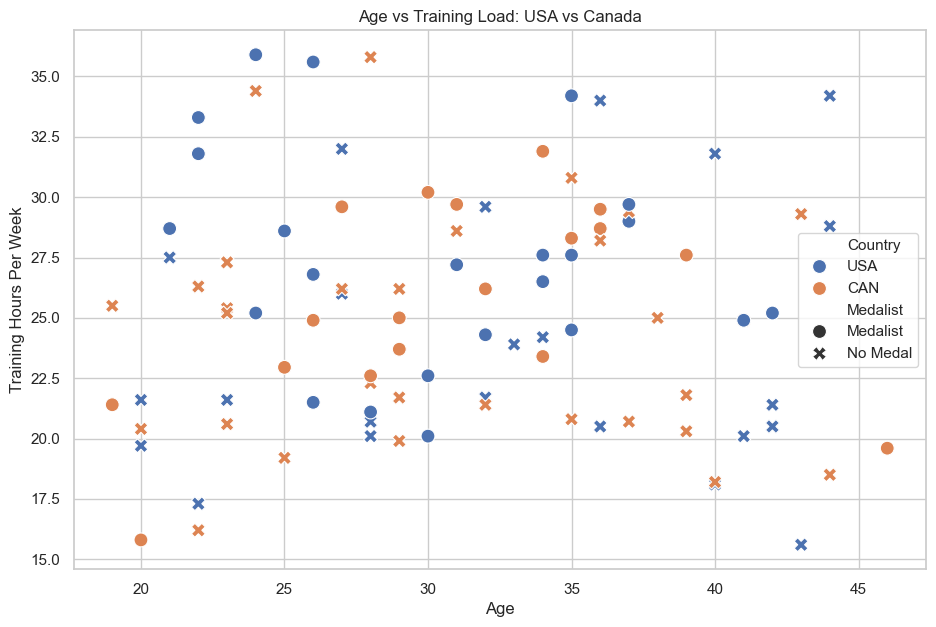

In [46]:
# Age vs Training Load
# USA vs Canada Medalists / Non-Medalists

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# USA + Canada only
na_df = df[df["Country"].isin(["USA", "CAN"])].copy()

# Medalist flag
na_df["Medalist"] = np.where(na_df["Medal_Group"] == "None", "No Medal", "Medalist")

plt.figure(figsize=(11,7))

sns.scatterplot(
    data=na_df,
    x="Age",
    y="Training_Hours_Per_Week",
    hue="Country",
    style="Medalist",
    s=100
)

plt.title("Age vs Training Load: USA vs Canada")
plt.xlabel("Age")
plt.ylabel("Training Hours Per Week")

plt.savefig(
    r"C:\Users\User\Desktop\Data Analytics Olympiad\24_age_training_USA_CAN.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

C:\Users\User\AppData\Local\Temp\ipykernel_24276\2080886910.py:26: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  na_df.groupby(["Training_Group","Country"])["Won_Medal"]


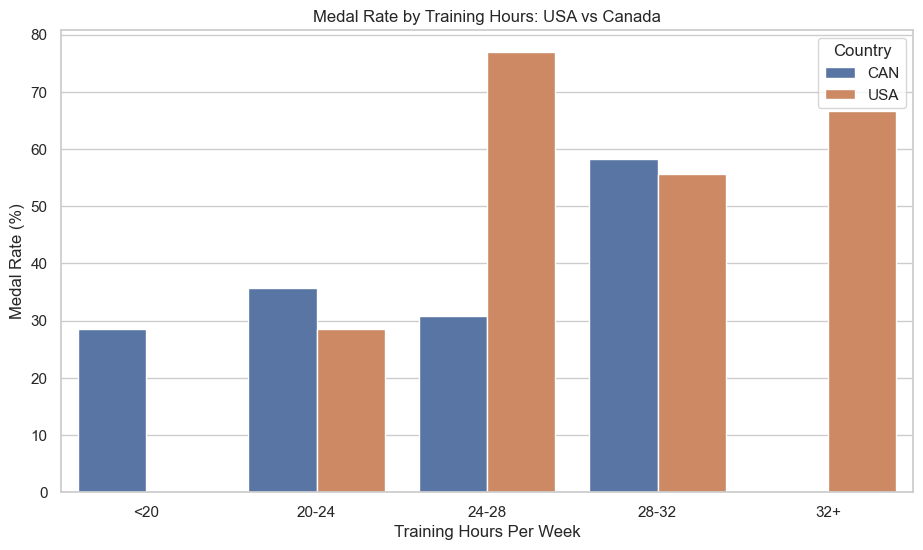

In [47]:
# Medal Rate by Training Range
# USA vs Canada

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# USA + Canada
na_df = df[df["Country"].isin(["USA", "CAN"])].copy()

# Medalist flag
na_df["Won_Medal"] = np.where(na_df["Medal_Group"] == "None", 0, 1)

# Training bins
na_df["Training_Group"] = pd.cut(
    na_df["Training_Hours_Per_Week"],
    bins=[0,20,24,28,32,40],
    labels=["<20","20-24","24-28","28-32","32+"]
)

# Medal %
rate = (
    na_df.groupby(["Training_Group","Country"])["Won_Medal"]
    .mean()
    .reset_index()
)

rate["Won_Medal"] *= 100

plt.figure(figsize=(11,6))

sns.barplot(
    data=rate,
    x="Training_Group",
    y="Won_Medal",
    hue="Country"
)

plt.title("Medal Rate by Training Hours: USA vs Canada")
plt.xlabel("Training Hours Per Week")
plt.ylabel("Medal Rate (%)")

plt.savefig(
r"C:\Users\User\Desktop\Data Analytics Olympiad\25_medal_rate_training_USA_CAN.png",
dpi=300,
bbox_inches="tight"
)

plt.show()

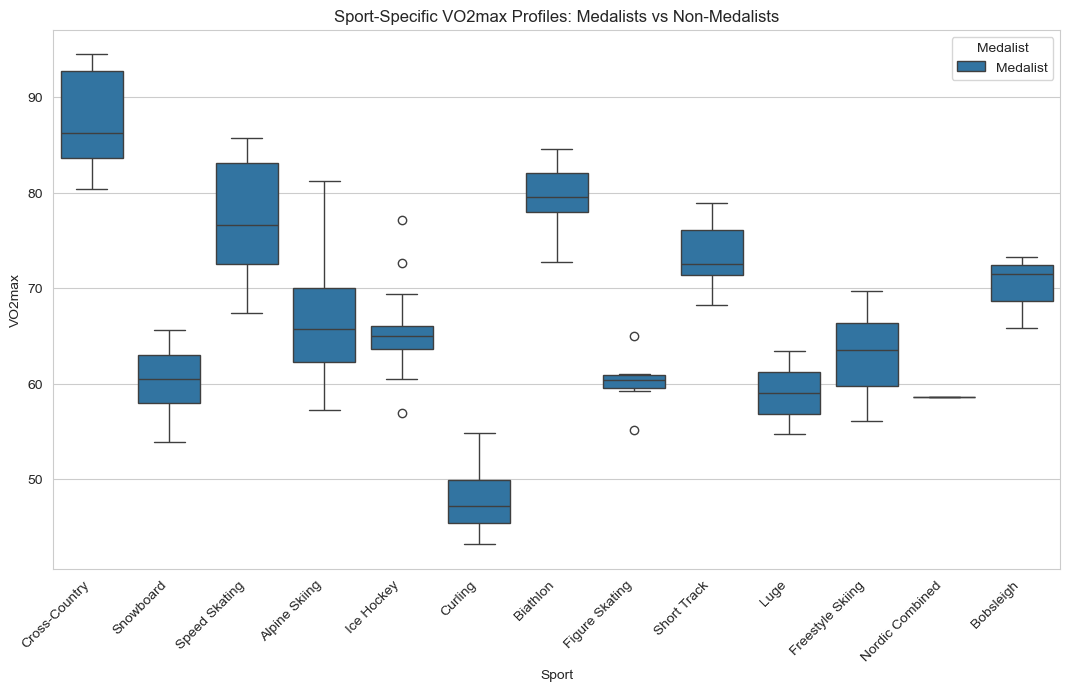

In [8]:
# Sport-Specific VO2max Thresholds
# USA vs Canada


import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# USA + Canada only
na_df = df[df["Country"].isin(["USA", "CAN"])].copy()

# Medalist flag
na_df["Medalist"] = np.where(na_df["Medal"] == "None", "No Medal", "Medalist")

plt.figure(figsize=(13,7))

sns.boxplot(
    data=na_df,
    x="Sport",
    y="VO2max",
    hue="Medalist"
)

plt.title("Sport-Specific VO2max Profiles: Medalists vs Non-Medalists")
plt.xlabel("Sport")
plt.ylabel("VO2max")
plt.xticks(rotation=45, ha="right")

plt.savefig(
    r"C:\Users\User\Desktop\Data Analytics Olympiad\26_sport_specific_vo2_thresholds.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()